# Lab 05_1. Logistic Classification

두 입력값으로 0과 1을 분류하는 로지스틱 분류 모델 만들기

## 목표

- Regression(리그레션, 회귀)과 Classification(클래시피케이션, 분류)의 차이 이해하기
- 선형 출력값 Logit(로짓, 시그모이드 적용 전 점수)을 확률로 변환하기
- Sigmoid Function(시그모이드 함수, 0과 1 사이로 변환하는 함수) 확인하기
- BCE(비씨이, 이진 교차엔트로피)의 계산 원리 이해하기
- `nn.Linear(2, 1)`과 `BCEWithLogitsLoss()`로 이진분류 모델 학습하기
- 0.5 임계값으로 클래스를 결정하고 Accuracy(애큐러시, 정확도) 계산하기
- 학습된 Decision Boundary(디시전 바운더리, 분류 경계) 확인하기

**Regression predicts a number; classification predicts a class.**  
**회귀는 숫자를 예측하고, 분류는 범주를 예측합니다.**

## 실습 단계

### 1. 라이브러리 불러오기

In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# 재현성: 난수 고정
np.random.seed(42)
torch.manual_seed(42)

print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.13.0+cu130


### 2. 이진분류 학습 데이터 만들기

- 입력 특성: 데이터마다 숫자 2개
- 목표값: 0 또는 1
- 입력 형상: `[6, 2]`
- 목표 형상: `[6, 1]`

이번 데이터는 분류 원리를 확인하기 위한 작은 학습 데이터입니다.

In [2]:
# 입력 특성 2개
x_data = torch.tensor(
    [
        [1.0, 2.0],
        [2.0, 3.0],
        [3.0, 1.0],
        [4.0, 3.0],
        [5.0, 3.0],
        [6.0, 2.0],
    ],
    dtype=torch.float32,
)

# 이진분류 목표값: 0 또는 1
y_data = torch.tensor(
    [[0.0], [0.0], [0.0], [1.0], [1.0], [1.0]],
    dtype=torch.float32,
)

print("입력 데이터:")
print(x_data)
print("\n목표값:")
print(y_data)
print("\n입력 형상:", x_data.shape)
print("목표 형상:", y_data.shape)

입력 데이터:
tensor([[1., 2.],
        [2., 3.],
        [3., 1.],
        [4., 3.],
        [5., 3.],
        [6., 2.]])

목표값:
tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])

입력 형상: torch.Size([6, 2])
목표 형상: torch.Size([6, 1])


### 3. 선형 출력값과 분류 확률 구분하기

먼저 두 입력값을 선형식으로 계산합니다.

$$
z=w_1x_1+w_2x_2+b
$$

- $z$: Logit(로짓, 시그모이드 적용 전 점수)
- 로짓의 범위: $-\infty$부터 $+\infty$
- 로짓은 아직 확률이 아님

로짓을 Sigmoid Function에 넣으면 0과 1 사이의 값이 됩니다.

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

$$
P(y=1|x)=\sigma(z)
$$

**The sigmoid function converts a logit into a value between 0 and 1.**  
**시그모이드 함수는 로짓을 0과 1 사이의 값으로 변환합니다.**

### 4. 시그모이드 함수 확인하기

로짓 -5.0 → 확률 0.0067
로짓  0.0 → 확률 0.5000
로짓  5.0 → 확률 0.9933


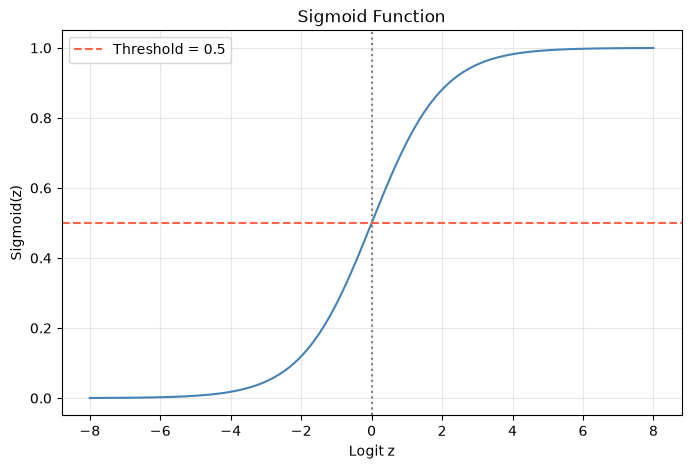

In [3]:
# 여러 로짓을 시그모이드 함수에 입력
logit_values = torch.linspace(-8, 8, 200)
probability_values = torch.sigmoid(logit_values)

sample_logits = torch.tensor([-5.0, 0.0, 5.0])
sample_probabilities = torch.sigmoid(sample_logits)

for logit, probability in zip(sample_logits, sample_probabilities):
    print(f"로짓 {logit.item():>4.1f} → 확률 {probability.item():.4f}")

plt.figure(figsize=(8, 5))
plt.plot(logit_values.numpy(), probability_values.numpy(), color="steelblue")
plt.axhline(0.5, color="tomato", linestyle="--", label="Threshold = 0.5")
plt.axvline(0, color="gray", linestyle=":")
plt.xlabel("Logit z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### 5. 0.5 임계값으로 클래스 결정하기

확률을 그대로 출력할 수도 있지만, 최종 분류 결과는 임계값과 비교해 결정합니다.

$$
\hat{y}=
\begin{cases}
1, & \sigma(z)\ge 0.5\\
0, & \sigma(z)<0.5
\end{cases}
$$

- 확률 0.5 이상 → 클래스 1
- 확률 0.5 미만 → 클래스 0
- 시그모이드 확률 0.5는 로짓 0에 해당

임계값 0.5는 기본값이며 문제의 목적에 따라 변경할 수 있습니다.

In [4]:
threshold = 0.5
sample_classes = (sample_probabilities >= threshold).float()

for probability, predicted_class in zip(sample_probabilities, sample_classes):
    print(
        f"확률 {probability.item():.4f} "
        f"→ 예측 클래스 {int(predicted_class.item())}"
    )

확률 0.0067 → 예측 클래스 0
확률 0.5000 → 예측 클래스 1
확률 0.9933 → 예측 클래스 1


### 6. 이진 교차엔트로피 이해하기

Binary Cross Entropy(바이너리 크로스 엔트로피, 이진 교차엔트로피)는 이진분류에서 사용하는 손실함수입니다.

$$
BCE=-\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i\log(p_i)+(1-y_i)\log(1-p_i)
\right]
$$

- 실제값이 1이면 $-\log(p)$ 계산
- 실제값이 0이면 $-\log(1-p)$ 계산
- 정답에 가까운 확률 → 손실이 작음
- 정답과 반대 방향으로 확신한 확률 → 손실이 매우 큼

**A confident wrong prediction receives a large loss.**  
**틀린 답을 확신할수록 큰 손실을 받습니다.**

In [5]:
# 손실 계산 예시
example_probabilities = torch.tensor([[0.9], [0.2]], dtype=torch.float32)
example_targets = torch.tensor([[1.0], [0.0]], dtype=torch.float32)

# 수식으로 BCE 직접 계산
manual_bce = -torch.mean(
    example_targets * torch.log(example_probabilities)
    + (1 - example_targets) * torch.log(1 - example_probabilities)
)

# PyTorch 손실함수로 계산
bce_loss_function = nn.BCELoss()
pytorch_bce = bce_loss_function(example_probabilities, example_targets)

print(f"수식으로 계산한 BCE: {manual_bce.item():.6f}")
print(f"PyTorch BCELoss:      {pytorch_bce.item():.6f}")
print(f"두 결과의 차이:       {abs(manual_bce.item() - pytorch_bce.item()):.10f}")

수식으로 계산한 BCE: 0.164252
PyTorch BCELoss:      0.164252
두 결과의 차이:       0.0000000149


### 7. 로지스틱 분류 모델 정의하기

`nn.Linear(2, 1)`은 두 입력값으로 로짓 하나를 만듭니다.

$$
z=w_1x_1+w_2x_2+b
$$

모델의 `forward()`에서는 시그모이드를 적용하지 않고 로짓을 그대로 반환합니다.

- 학습: `BCEWithLogitsLoss()`에 로짓 입력
- 예측: `torch.sigmoid(logits)`로 확률 변환

이 방식은 `Sigmoid + BCELoss`를 하나로 계산하므로 수치적으로 더 안정적입니다.

In [6]:
class LogisticClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 입력 특성 2개 → 로짓 1개
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        # 시그모이드 적용 전 로짓 반환
        logits = self.linear(x)
        return logits


model = LogisticClassificationModel()

# 학습 시작값을 일정하게 설정
nn.init.zeros_(model.linear.weight)
nn.init.zeros_(model.linear.bias)

print(model)
print("초기 가중치:", model.linear.weight.detach())
print("초기 편향:", model.linear.bias.detach())

LogisticClassificationModel(
  (linear): Linear(in_features=2, out_features=1, bias=True)
)
초기 가중치: tensor([[0., 0.]])
초기 편향: tensor([0.])


### 8. 두 가지 BCE 계산 방식 비교하기

다음 두 방식은 같은 손실을 계산합니다.

1. `torch.sigmoid(logits)` → `nn.BCELoss()`
2. `logits` → `nn.BCEWithLogitsLoss()`

실제 학습에서는 두 번째 방식을 권장합니다.

In [7]:
comparison_logits = torch.tensor(
    [[-2.0], [0.5], [2.0]],
    dtype=torch.float32,
)
comparison_targets = torch.tensor(
    [[0.0], [1.0], [1.0]],
    dtype=torch.float32,
)

# 방식 1: 시그모이드 적용 후 BCE
loss_after_sigmoid = nn.BCELoss()(
    torch.sigmoid(comparison_logits),
    comparison_targets,
)

# 방식 2: 로짓을 안정적으로 직접 처리
loss_from_logits = nn.BCEWithLogitsLoss()(
    comparison_logits,
    comparison_targets,
)

print(f"Sigmoid + BCELoss:       {loss_after_sigmoid.item():.6f}")
print(f"BCEWithLogitsLoss:       {loss_from_logits.item():.6f}")
print(f"두 결과의 차이:          {abs(loss_after_sigmoid.item() - loss_from_logits.item()):.10f}")

Sigmoid + BCELoss:       0.242644
BCEWithLogitsLoss:       0.242644
두 결과의 차이:          0.0000000149


### 9. 손실함수와 최적화 도구 정의하기

- 손실함수: `nn.BCEWithLogitsLoss()`
- 최적화 도구: SGD(에스지디, 확률적 경사하강법)
- 학습 대상: 가중치 2개와 편향 1개
- 학습률: 0.1

In [8]:
# 로짓과 정답으로 이진 교차엔트로피 계산
loss_function = nn.BCEWithLogitsLoss()

# 경사하강법으로 가중치와 편향 갱신
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

### 10. 모델 학습하기

1. 입력 데이터로 로짓 계산
2. BCE 손실 계산
3. 이전 기울기 초기화
4. `backward()`로 기울기 계산
5. `step()`으로 가중치와 편향 갱신

In [9]:
epochs = 3000
loss_history = []

model.train()

for epoch in range(epochs):
    # 순전파: 로짓 계산
    logits = model(x_data)

    # 이진 교차엔트로피 손실
    loss = loss_function(logits, y_data)

    # 기울기 초기화·역전파·갱신
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 손실 기록
    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss {loss.item():.6f}")

print(f"Epoch {epochs - 1:4d} | Loss {loss_history[-1]:.6f}")

Epoch    0 | Loss 0.693147
Epoch  500 | Loss 0.233518
Epoch 1000 | Loss 0.147375
Epoch 1500 | Loss 0.107644
Epoch 2000 | Loss 0.084996
Epoch 2500 | Loss 0.070357
Epoch 2999 | Loss 0.060115


### 11. 손실 변화 확인하기

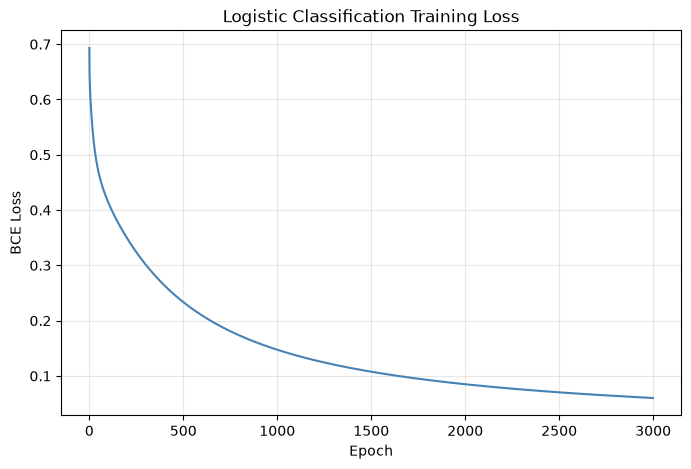

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Logistic Classification Training Loss")
plt.grid(alpha=0.3)
plt.show()

### 12. 확률·클래스·정확도 계산하기

학습이 끝난 뒤 로짓을 확률과 클래스로 변환합니다.

$$
probability=\sigma(logit)
$$

$$
predicted=(probability\ge0.5)
$$

Accuracy(애큐러시, 정확도)는 전체 데이터 중 정답을 맞힌 비율입니다.

$$
Accuracy=\frac{정답을\ 맞힌\ 데이터\ 수}{전체\ 데이터\ 수}
$$

In [11]:
model.eval()

with torch.no_grad():
    # 로짓 → 확률 → 클래스
    trained_logits = model(x_data)
    probabilities = torch.sigmoid(trained_logits)
    predicted_classes = (probabilities >= threshold).float()

    # 정확도
    accuracy = (predicted_classes == y_data).float().mean()

print("학습된 가중치:", model.linear.weight.detach())
print("학습된 편향:", model.linear.bias.detach())
print(f"정확도: {accuracy.item():.4f}")

print("\n입력             확률      예측  실제")
for x, probability, predicted, actual in zip(
    x_data,
    probabilities,
    predicted_classes,
    y_data,
):
    print(
        f"{x.tolist()}  "
        f"{probability.item():.4f}    "
        f"{int(predicted.item())}     "
        f"{int(actual.item())}"
    )

학습된 가중치: tensor([[2.2128, 0.9097]])
학습된 편향: tensor([-9.5349])
정확도: 1.0000

입력             확률      예측  실제
[1.0, 2.0]  0.0041    0     0
[2.0, 3.0]  0.0847    0     0
[3.0, 1.0]  0.1206    0     0
[4.0, 3.0]  0.8855    1     1
[5.0, 3.0]  0.9861    1     1
[6.0, 2.0]  0.9962    1     1


### 13. 분류 결과를 세부적으로 확인하기

- TP(티피, 실제 1을 1로 예측)
- TN(티엔, 실제 0을 0으로 예측)
- FP(에프피, 실제 0을 1로 잘못 예측)
- FN(에프엔, 실제 1을 0으로 잘못 예측)

이번 데이터는 클래스 0과 1이 각각 3개이므로 Accuracy를 직관적으로 확인하기 좋습니다.  
다만 데이터가 6개뿐이므로 일반화 성능을 평가한 결과는 아닙니다.

In [12]:
actual_classes = y_data.bool()
predicted_bool = predicted_classes.bool()

true_positive = torch.sum(predicted_bool & actual_classes).item()
true_negative = torch.sum((~predicted_bool) & (~actual_classes)).item()
false_positive = torch.sum(predicted_bool & (~actual_classes)).item()
false_negative = torch.sum((~predicted_bool) & actual_classes).item()

print("TP:", true_positive)
print("TN:", true_negative)
print("FP:", false_positive)
print("FN:", false_negative)

TP: 3
TN: 3
FP: 0
FN: 0


### 14. 학습된 분류 경계 확인하기

확률 0.5에 해당하는 로짓은 0입니다.

$$
w_1x_1+w_2x_2+b=0
$$

이 직선이 클래스 0과 클래스 1을 나누는 Decision Boundary(디시전 바운더리, 분류 경계)입니다.

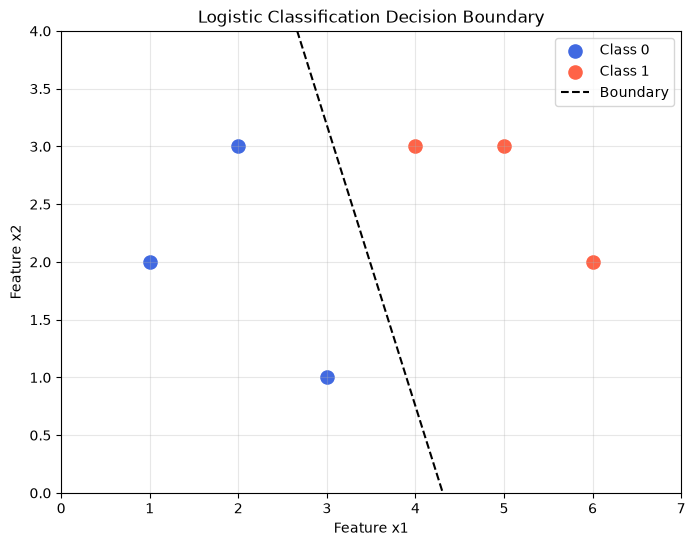

In [13]:
# 학습된 가중치와 편향
weight_1 = model.linear.weight.detach()[0, 0].item()
weight_2 = model.linear.weight.detach()[0, 1].item()
bias = model.linear.bias.detach()[0].item()

# w1*x1 + w2*x2 + b = 0을 x2에 대해 정리
x1_line = np.linspace(0, 7, 200)
x2_line = -(weight_1 * x1_line + bias) / weight_2

x_numpy = x_data.numpy()
y_numpy = y_data.squeeze().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(
    x_numpy[y_numpy == 0, 0],
    x_numpy[y_numpy == 0, 1],
    color="royalblue",
    s=90,
    label="Class 0",
)
plt.scatter(
    x_numpy[y_numpy == 1, 0],
    x_numpy[y_numpy == 1, 1],
    color="tomato",
    s=90,
    label="Class 1",
)
plt.plot(x1_line, x2_line, color="black", linestyle="--", label="Boundary")
plt.xlim(0, 7)
plt.ylim(0, 4)
plt.xlabel("Feature x1")
plt.ylabel("Feature x2")
plt.title("Logistic Classification Decision Boundary")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 확인 실습

새로운 입력값 3개를 모델에 넣어 확률과 클래스를 예측합니다.

- 모델 학습에 사용하지 않은 입력 형식 확인
- 로짓과 확률의 차이 확인
- 0.5 임계값으로 최종 클래스 결정

In [14]:
new_x = torch.tensor(
    [[2.0, 1.0], [4.0, 2.0], [6.0, 4.0]],
    dtype=torch.float32,
)

model.eval()

with torch.no_grad():
    new_logits = model(new_x)
    new_probabilities = torch.sigmoid(new_logits)
    new_classes = (new_probabilities >= threshold).float()

print("입력             로짓       확률      예측")
for x, logit, probability, predicted in zip(
    new_x,
    new_logits,
    new_probabilities,
    new_classes,
):
    print(
        f"{x.tolist()}  "
        f"{logit.item():8.4f}  "
        f"{probability.item():.4f}    "
        f"{int(predicted.item())}"
    )

입력             로짓       확률      예측
[2.0, 1.0]   -4.1996  0.0148    0
[4.0, 2.0]    1.1358  0.7569    1
[6.0, 4.0]    7.3808  0.9994    1


## 실행 확인

아래 셀에서 오류가 없으면 `Lab 05_1`이 정상적으로 완료된 것입니다.

In [15]:
assert x_data.shape == torch.Size([6, 2])
assert y_data.shape == torch.Size([6, 1])
assert trained_logits.shape == torch.Size([6, 1])
assert probabilities.shape == torch.Size([6, 1])
assert torch.all((probabilities >= 0) & (probabilities <= 1))
assert torch.equal(predicted_classes, y_data)
assert accuracy.item() == 1.0
assert abs(loss_after_sigmoid.item() - loss_from_logits.item()) < 1e-6
assert loss_history[-1] < loss_history[0]

print("Lab 05_1 실행 확인 완료")

Lab 05_1 실행 확인 완료


## 핵심 정리

- 문제: 입력 특성 2개로 클래스 0 또는 1 예측
- 선형계층: `nn.Linear(2, 1)`
- 모델 출력: 시그모이드 적용 전 Logit
- 확률 변환: `torch.sigmoid(logits)`
- 손실함수: `nn.BCEWithLogitsLoss()`
- 최적화 도구: `SGD`
- 분류 기준: 확률 0.5
- 평가: Accuracy와 TP·TN·FP·FN
- 분류 경계: $w_1x_1+w_2x_2+b=0$
- 이번 정확도: 학습 데이터 적합도 확인
- 일반화 성능: 더 많은 데이터를 훈련·테스트로 분리한 뒤 평가
- 다음 단계: `Lab 05_2`에서 CSV 기반 실제 이진분류 데이터 적용